# 1. Phase 5A Objective and Evidence Boundary

**Question.** Do simple models improve on fair-random and historical baselines?

**Method.** Fit only Phase 4 train rows, tune with expanding chronological folds, and score only Phase 4 validation rows.

**Interpretation.** The report contains historical validation backtests only.

**Limitation.** A validation result does not establish future predictive ability.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd()
if not (ROOT / 'reports/phase5a_metrics.json').is_file():
    ROOT = next(parent for parent in Path.cwd().parents if (parent / 'reports/phase5a_metrics.json').is_file())
metrics = json.loads((ROOT / 'reports/phase5a_metrics.json').read_text(encoding='utf-8'))
validation = json.loads((ROOT / 'reports/phase5a_validation.json').read_text(encoding='utf-8'))
pred3 = pd.read_csv(ROOT / 'reports/phase5a_validation_predictions/3d_validation_predictions.csv')
pred6 = pd.read_csv(ROOT / 'reports/phase5a_validation_predictions/642_validation_predictions.csv')
simulations = pd.read_csv(ROOT / 'reports/phase5a_random_baseline_distributions.csv')
print('Phase:', metrics['phase'], '| Evidence verdict:', metrics['advancement_gate']['verdict'])
print('Validation predictions:', len(pred3), '3D rows and', len(pred6), '6/42 rows')

Phase: PHASE_5A | Evidence verdict: PHASE5A_INCONCLUSIVE
Validation predictions: 723 3D rows and 300 6/42 rows


# 2. Phase 4 Inputs and Split Verification

**Question.** Do the input files and chronological partitions match the approved Phase 4 artifacts?

**Method.** Read the saved Phase 4 split manifest and hash-validated preflight record; no target file is reopened here.

**Interpretation.** The training, validation, and locked-test boundaries are shown from manifest metadata.

**Limitation.** This notebook consumes saved validation outputs and does not rebuild Phase 4 features.


In [2]:
split = json.loads((ROOT / 'data/features/chronological_splits.json').read_text(encoding='utf-8'))
split_rows = []
for game, spec in split['games'].items():
    for partition, item in spec['partitions'].items():
        split_rows.append({'game': game, 'partition': partition, 'rows': item['row_count'], 'start': item['start_date'], 'end': item['end_date']})
pd.DataFrame(split_rows)

,game,partition,rows,start,end
0,3d_lotto,test,724,2024-10-08,2026-10-07
1,3d_lotto,train,2170,2016-04-16,2022-10-03
2,3d_lotto,validation,723,2022-10-04,2024-10-07
3,lotto_6_42,test,302,2024-10-24,2026-10-06
4,lotto_6_42,train,902,2016-08-30,2022-11-12
5,lotto_6_42,validation,300,2022-11-15,2024-10-22


# 3. Locked Test Safeguard

**Question.** Were locked test target values kept out of training, selection, scoring, and charts?

**Method.** Review the machine-readable audit flags and report only test partition metadata.

**Interpretation.** No test targets were parsed by the Phase 5A model or evaluation paths.

**Limitation.** The locked test is still needed for a separately authorized later gate.


In [3]:
audit = metrics['test_contamination_audit']
assert audit['test_target_values_loaded'] is False
assert audit['test_metrics_calculated'] is False
assert audit['phase4_boundaries_preserved'] is True
print(json.dumps(audit, indent=2))

{
  "test_target_values_loaded": false,
  "test_targets_used_for_fit": false,
  "test_targets_used_for_selection": false,
  "test_metrics_calculated": false,
  "test_target_dependent_visualization": false,
  "candidate_selected_using_test_information": false,
  "phase4_boundaries_preserved": true,
  "all_checks_pass": true,
  "test_file_handling": "row counts and Phase 4 manifest metadata only; no test target cells parsed"
}


# 4. Evaluation Metrics and Predeclared Baselines

**Question.** Which metrics and baselines define a useful comparison?

**Method.** Use normalized unordered-multiset NLL and overlap for 3D; use mean hits@6 for Lotto 6/42, with Brier, marginal log loss, match counts, and Jaccard as secondary diagnostics.

**Interpretation.** The metrics table is loaded from the saved configuration.

**Limitation.** Different games have different outcome spaces and are not compared numerically to each other.


In [4]:
pd.DataFrame(metrics['metric_definitions'])

,game,metric,formula,direction
0,3d_lotto,mean_multinomial_negative_log_likelihood_per_d...,-log((3! / product(count[d]!)) * product(p[d]^...,lower_is_better
1,3d_lotto,mean_multiset_overlap,"sum_d min(actual_count[d], Hamilton_allocated_...",higher_is_better
2,3d_lotto,digit_level_multiclass_brier,mean across the three unordered digit observat...,lower_is_better
3,lotto_6_42,mean_hits_at_6,mean size of intersection between predicted si...,higher_is_better
4,lotto_6_42,42-label Brier,mean across draws and 42 membership labels of ...,lower_is_better
5,lotto_6_42,marginal log loss,mean binary log loss across draws and 42 membe...,lower_is_better


# 5. 3D Lotto Baselines

**Question.** How do uniform probabilities and expanding historical digit frequencies score?

**Method.** Score both with the same unordered-multiset likelihood, digit Brier score, and deterministic Hamilton allocated overlap.

**Interpretation.** The uniform and historical baselines are summarized below.

**Limitation.** Historical features use only completed draws before each validation prediction.


In [5]:
rows = []
for method in ['uniform_random', 'expanding_historical_frequency', 'multinomial_logistic_regression/all_features']:
    item = metrics['validation']['3d_lotto']['methods'][method]
    rows.append({'method': method, 'unordered_nll_per_digit': item['mean_multinomial_negative_log_likelihood_per_digit'], 'mean_multiset_overlap': item['mean_multiset_overlap'], 'digit_brier': item['digit_level_multiclass_brier'], 'ece': item['calibration']['expected_calibration_error']})
pd.DataFrame(rows)

,method,unordered_nll_per_digit,mean_multiset_overlap,digit_brier,ece
0,uniform_random,1.773298,0.742596,0.900000,0.000000
1,expanding_historical_frequency,1.773773,0.845090,0.900094,0.002117
2,multinomial_logistic_regression/all_features,1.899246,0.799447,0.929506,0.039699


# 6. 3D Multinomial Model

**Question.** Does count-weighted multinomial logistic regression learn a useful digit distribution?

**Method.** Expand each training draw into three digit observations, scale features inside each training fold, and select C only by expanding-window NLL.

**Interpretation.** The final selected C and validation metrics are recorded below.

**Limitation.** The independence model uses one categorical digit distribution for an unordered draw.


In [6]:
from IPython.display import display
display(pd.DataFrame([metrics['cv']['selection']['3d_lotto']['logistic']['all_features']]))
pd.DataFrame([{'method': 'multinomial_logistic_regression/all_features', 'nll_per_digit': metrics['validation']['3d_lotto']['methods']['multinomial_logistic_regression/all_features']['mean_multinomial_negative_log_likelihood_per_digit'], 'overlap': metrics['validation']['3d_lotto']['methods']['multinomial_logistic_regression/all_features']['mean_multiset_overlap']}])

,selected_c,selection_metric,candidate_scores
0,0.1,mean_multinomial_negative_log_likelihood_per_d...,"[{'c': 0.1, 'fold_mean_nll': [2.84735603852466..."


,method,nll_per_digit,overlap
0,multinomial_logistic_regression/all_features,1.899246,0.799447


# 7. 3D Chronological Validation Results

**Question.** Were predictions formed using only earlier rows within each training fold?

**Method.** Inspect fold date windows and selected-model scores against fold-specific uniform and expanding-frequency baselines.

**Interpretation.** The fold table and chronology diagram expose training and prediction order.

**Limitation.** Three folds provide limited evidence about regime stability.


In [7]:
folds = pd.DataFrame(metrics['cv']['fold_results'])
folds.query("game == '3d_lotto' and feature_group == 'all_features' and model == 'multinomial_logistic_regression'")

,game,model,feature_group,c,fold,train_start_date,train_end_date,validation_start_date,validation_end_date,train_rows,validation_rows,mean_multinomial_negative_log_likelihood_per_digit,uniform_nll,expanding_frequency_nll,mean_multiset_overlap,mean_hits_at_6,fair_random_expected_hits,expanding_frequency_hits,recent_30_frequency_hits
27,3d_lotto,multinomial_logistic_regression,all_features,0.1,1,2016-04-16,2017-10-17,2017-10-18,2019-04-26,544,542,2.847356,1.771552,1.773614,0.651292,NaN,NaN,NaN,NaN
28,3d_lotto,multinomial_logistic_regression,all_features,0.1,2,2016-04-16,2019-04-26,2019-04-27,2021-03-30,1086,542,2.271701,1.779048,1.779957,0.739852,NaN,NaN,NaN,NaN
29,3d_lotto,multinomial_logistic_regression,all_features,0.1,3,2016-04-16,2021-03-30,2021-03-31,2022-10-03,1628,542,1.975869,1.777093,1.778047,0.802583,NaN,NaN,NaN,NaN
30,3d_lotto,multinomial_logistic_regression,all_features,1.0,1,2016-04-16,2017-10-17,2017-10-18,2019-04-26,544,542,4.989499,1.771552,1.773614,0.529520,NaN,NaN,NaN,NaN
31,3d_lotto,multinomial_logistic_regression,all_features,1.0,2,2016-04-16,2019-04-26,2019-04-27,2021-03-30,1086,542,2.612930,1.779048,1.779957,0.697417,NaN,NaN,NaN,NaN
32,3d_lotto,multinomial_logistic_regression,all_features,1.0,3,2016-04-16,2021-03-30,2021-03-31,2022-10-03,1628,542,2.140306,1.777093,1.778047,0.782288,NaN,NaN,NaN,NaN
33,3d_lotto,multinomial_logistic_regression,all_features,10.0,1,2016-04-16,2017-10-17,2017-10-18,2019-04-26,544,542,6.231862,1.771552,1.773614,0.518450,NaN,NaN,NaN,NaN
34,3d_lotto,multinomial_logistic_regression,all_features,10.0,2,2016-04-16,2019-04-26,2019-04-27,2021-03-30,1086,542,2.595017,1.779048,1.779957,0.756458,NaN,NaN,NaN,NaN
35,3d_lotto,multinomial_logistic_regression,all_features,10.0,3,2016-04-16,2021-03-30,2021-03-31,2022-10-03,1628,542,2.362346,1.777093,1.778047,0.715867,NaN,NaN,NaN,NaN


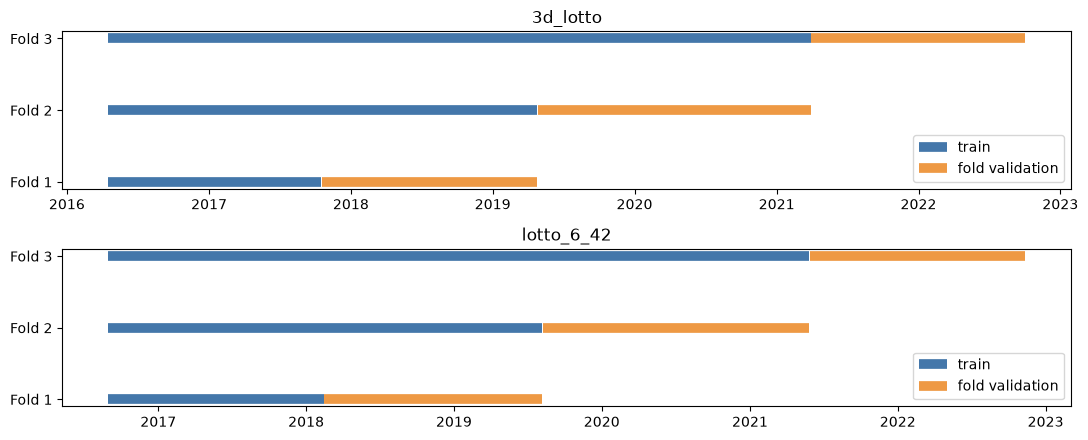

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(11, 4.5), sharex=False)
for ax, game in zip(axes, ['3d_lotto', 'lotto_6_42']):
    rows = [row for row in metrics['cv']['fold_windows'][game]]
    for y, row in enumerate(rows):
        ax.plot([pd.to_datetime(row['train_start_date']), pd.to_datetime(row['train_end_date'])], [y, y], color='#4477aa', linewidth=7, solid_capstyle='butt', label='train' if y == 0 else None)
        ax.plot([pd.to_datetime(row['validation_start_date']), pd.to_datetime(row['validation_end_date'])], [y, y], color='#ee9944', linewidth=7, solid_capstyle='butt', label='fold validation' if y == 0 else None)
    ax.set_yticks(range(len(rows)), [f"Fold {row['fold']}" for row in rows])
    ax.set_title(game)
    ax.legend(loc='lower right')
fig.tight_layout()
plt.show()

# 8. 3D Random-Baseline Comparison

**Question.** Is the deterministic model overlap unusual under fair random multiset draws?

**Method.** Compare its mean validation overlap with 10,000 or, after the predeclared p-value trigger, 100,000 Monte Carlo fair-random simulations.

**Interpretation.** The empirical p-value and simulation distribution are shown below.

**Limitation.** Overlap is secondary to the primary multiset likelihood and does not imply number predictability.


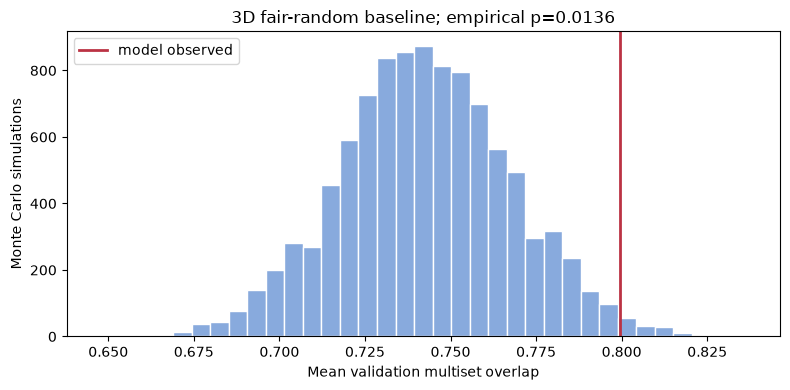

In [9]:
mc3 = metrics['random_baseline']['games']['3d_lotto']
run3 = 'confirmation' if mc3['confirmation_triggered'] else 'initial'
dist3 = simulations.query("game == '3d_lotto' and run == @run3")['mean_primary_score']
plt.figure(figsize=(8, 4))
plt.hist(dist3, bins=35, color='#88aadd', edgecolor='white')
plt.axvline(mc3['candidates']['multinomial_logistic_regression/all_features']['observed_score'], color='#bb3344', linewidth=2, label='model observed')
plt.xlabel('Mean validation multiset overlap')
plt.ylabel('Monte Carlo simulations')
plt.title(f"3D fair-random baseline; empirical p={mc3['candidates']['multinomial_logistic_regression/all_features']['empirical_p_final']:.4g}")
plt.legend()
plt.tight_layout()
plt.show()

# 9. Lotto 6/42 Baselines

**Question.** How do uniform marginal probabilities and simple history rankings perform?

**Method.** Compare fair-random expected hits, expanding historical frequency, and previous-30-draw frequency on validation rows.

**Interpretation.** The baseline table includes hit, Brier, marginal log loss, and Jaccard summaries.

**Limitation.** Frequency rankings are baseline definitions and are not presented as actionable number advice.


In [10]:
rows = []
for method in ['uniform_random', 'expanding_historical_frequency', 'recent_30_frequency']:
    item = metrics['validation']['lotto_6_42']['methods'][method]
    rows.append({'method': method, 'mean_hits_at_6': item['mean_hits_at_6'], 'brier': item['mean_brier_42_label'], 'marginal_log_loss': item['mean_marginal_log_loss'], 'jaccard': item['mean_jaccard_similarity']})
pd.DataFrame(rows)

,method,mean_hits_at_6,brier,marginal_log_loss,jaccard
0,uniform_random,0.857143,0.122449,0.410116,NaN
1,expanding_historical_frequency,0.900000,0.122591,0.410704,0.087333
2,recent_30_frequency,0.793333,0.126724,0.473228,0.077091


# 10. Lotto 6/42 Logistic Model

**Question.** Does regularized one-versus-rest logistic regression improve mean hits@6?

**Method.** Scale features inside each chronological training fold and select C using only fold hit counts.

**Interpretation.** The all-feature validation comparison is shown below.

**Limitation.** The output is a backtest for historical validation rows, not a future draw.


In [11]:
from IPython.display import display
display(pd.DataFrame([metrics['cv']['selection']['lotto_6_42']['logistic']['all_features']]))
item = metrics['validation']['lotto_6_42']['methods']['regularized_one_vs_rest_logistic_regression/all_features']
pd.DataFrame([{'mean_hits_at_6': item['mean_hits_at_6'], 'recall_at_6': item['mean_recall_at_6'], 'precision_at_6': item['mean_precision_at_6'], 'brier': item['mean_brier_42_label'], 'marginal_log_loss': item['mean_marginal_log_loss'], 'jaccard': item['mean_jaccard_similarity']}])

,selected_c,selection_metric,candidate_scores
0,1.0,mean_hits_at_6,"[{'c': 0.1, 'fold_mean_hits_at_6': [0.92, 0.84..."


,mean_hits_at_6,recall_at_6,precision_at_6,brier,marginal_log_loss,jaccard
0,0.923333,0.153889,0.153889,0.37124,2.604837,0.089354


# 11. Lotto 6/42 Nonlinear Comparator

**Question.** Does the fixed multioutput random forest add evidence beyond the simpler logistic model?

**Method.** Use the one predeclared bounded forest configuration without a parameter search.

**Interpretation.** The fixed comparator’s validation and fold results are shown beside logistic regression.

**Limitation.** The forest is a comparator, not the preferred model by default.


In [12]:
item = metrics['validation']['lotto_6_42']['methods']['random_forest_multioutput_comparator/all_features']
display(pd.DataFrame([{'mean_hits_at_6': item['mean_hits_at_6'], 'brier': item['mean_brier_42_label'], 'marginal_log_loss': item['mean_marginal_log_loss'], 'jaccard': item['mean_jaccard_similarity']}]))
pd.DataFrame(folds.query("game == 'lotto_6_42' and feature_group == 'all_features' and model == 'random_forest_multioutput_comparator'"))

,mean_hits_at_6,brier,marginal_log_loss,jaccard
0,0.883333,0.123135,0.412987,0.085293


,game,model,feature_group,c,fold,train_start_date,train_end_date,validation_start_date,validation_end_date,train_rows,validation_rows,mean_multinomial_negative_log_likelihood_per_digit,uniform_nll,expanding_frequency_nll,mean_multiset_overlap,mean_hits_at_6,fair_random_expected_hits,expanding_frequency_hits,recent_30_frequency_hits
81,lotto_6_42,random_forest_multioutput_comparator,all_features,NaN,1,2016-08-30,2018-02-13,2018-02-15,2019-08-06,227,225,NaN,NaN,NaN,NaN,0.831111,0.857143,0.835556,0.835556
82,lotto_6_42,random_forest_multioutput_comparator,all_features,NaN,2,2016-08-30,2019-08-06,2019-08-08,2021-05-27,452,225,NaN,NaN,NaN,NaN,0.853333,0.857143,0.813333,0.866667
83,lotto_6_42,random_forest_multioutput_comparator,all_features,NaN,3,2016-08-30,2021-05-27,2021-05-29,2022-11-12,677,225,NaN,NaN,NaN,NaN,0.924444,0.857143,0.871111,0.866667


# 12. Lotto 6/42 Chronological Validation Results

**Question.** Do the selected models beat fair-random and historical baselines on the full validation window?

**Method.** Compare mean hits@6 and its draw-level bootstrap interval across all predeclared methods.

**Interpretation.** The bar chart shows baseline and all-feature candidate mean hits.

**Limitation.** A small absolute hit-count difference can arise from validation sampling noise.


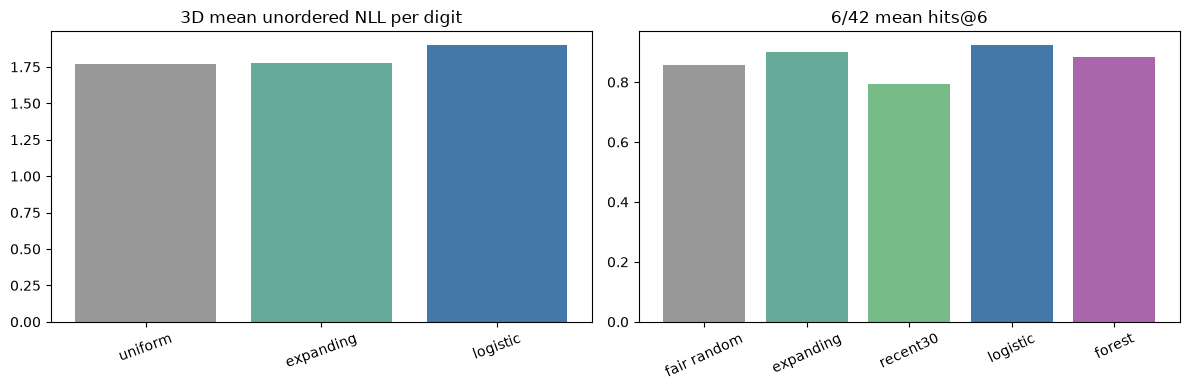

In [13]:
primary3 = metrics['validation']['3d_lotto']['methods']
primary6 = metrics['validation']['lotto_6_42']['methods']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['uniform', 'expanding', 'logistic'], [primary3['uniform_random']['mean_multinomial_negative_log_likelihood_per_digit'], primary3['expanding_historical_frequency']['mean_multinomial_negative_log_likelihood_per_digit'], primary3['multinomial_logistic_regression/all_features']['mean_multinomial_negative_log_likelihood_per_digit']], color=['#999999', '#66aa99', '#4477aa'])
axes[0].set_title('3D mean unordered NLL per digit')
axes[0].tick_params(axis='x', rotation=20)
axes[1].bar(['fair random', 'expanding', 'recent30', 'logistic', 'forest'], [primary6['uniform_random']['mean_hits_at_6'], primary6['expanding_historical_frequency']['mean_hits_at_6'], primary6['recent_30_frequency']['mean_hits_at_6'], primary6['regularized_one_vs_rest_logistic_regression/all_features']['mean_hits_at_6'], primary6['random_forest_multioutput_comparator/all_features']['mean_hits_at_6']], color=['#999999', '#66aa99', '#77bb88', '#4477aa', '#aa66aa'])
axes[1].set_title('6/42 mean hits@6')
axes[1].tick_params(axis='x', rotation=25)
fig.tight_layout()
plt.show()

# 13. Lotto 6/42 Random-Baseline Comparison

**Question.** Are model hit counts unusual compared with fair random six-number sets?

**Method.** Use the exact hypergeometric hit law for each random six-set simulation and the same number of validation draws.

**Interpretation.** Both all-feature models are marked against a shared Monte Carlo distribution.

**Limitation.** Empirical p-values are exploratory and are adjusted for the two predefined all-feature candidate comparisons in the gate.


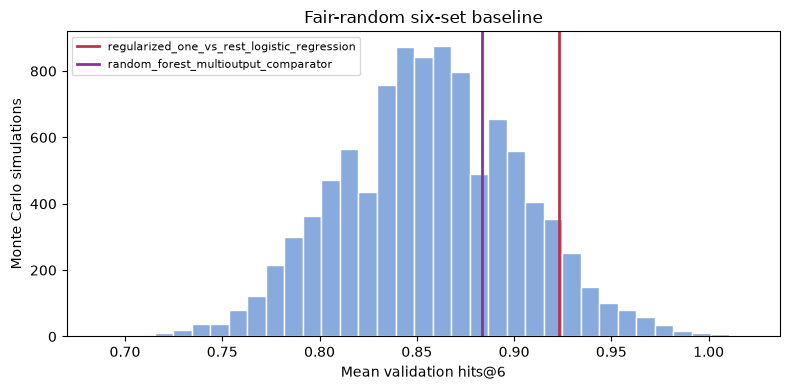

,empirical_p_initial,empirical_p_final,empirical_p_bonferroni,confirmation_simulations
regularized_one_vs_rest_logistic_regression,0.082692,0.082692,0.165383,0
random_forest_multioutput_comparator,0.293171,0.293171,0.586341,0


In [14]:
mc6 = metrics['random_baseline']['games']['lotto_6_42']
run6 = 'confirmation' if mc6['confirmation_triggered'] else 'initial'
dist6 = simulations.query("game == 'lotto_6_42' and run == @run6")['mean_primary_score']
plt.figure(figsize=(8, 4))
plt.hist(dist6, bins=35, color='#88aadd', edgecolor='white')
for method, color in [('regularized_one_vs_rest_logistic_regression', '#bb3344'), ('random_forest_multioutput_comparator', '#883399')]:
    observed = mc6['candidates'][method]['observed_score']
    plt.axvline(observed, color=color, linewidth=2, label=method)
plt.xlabel('Mean validation hits@6')
plt.ylabel('Monte Carlo simulations')
plt.title('Fair-random six-set baseline')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()
pd.DataFrame(mc6['candidates']).T[['empirical_p_initial', 'empirical_p_final', 'empirical_p_bonferroni', 'confirmation_simulations']]

# 14. Feature-Group Ablation

**Question.** Are apparent results stable across the predefined feature families?

**Method.** Compare frequency/deviation, recency/gap, draw-context, and all-feature models; each logistic group’s C was chosen only in training folds.

**Interpretation.** The primary metric plot compares the four fixed groups.

**Limitation.** Ablation results are diagnostics and do not define arbitrary subsets.


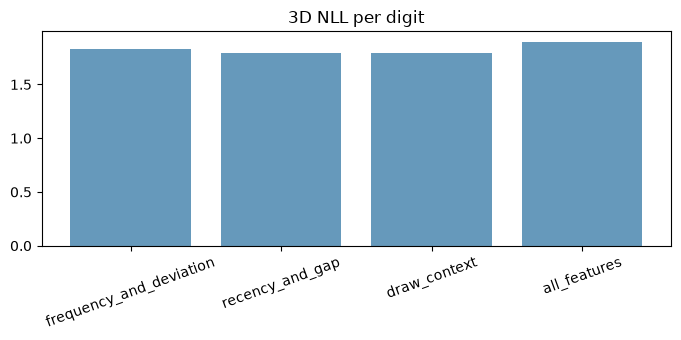

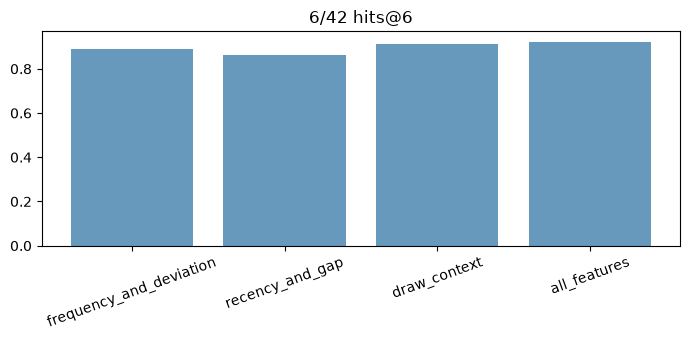

,game,model,feature_group,selected_c,mean_multinomial_negative_log_likelihood_per_digit,mean_multiset_overlap,digit_level_multiclass_brier,mean_hits_at_6,mean_brier_42_label,mean_marginal_log_loss,mean_jaccard_similarity
0,3d_lotto,multinomial_logistic_regression,frequency_and_deviation,0.1,1.832436,0.838174,0.913292,NaN,NaN,NaN,NaN
1,3d_lotto,multinomial_logistic_regression,recency_and_gap,0.1,1.788949,0.756570,0.903158,NaN,NaN,NaN,NaN
2,3d_lotto,multinomial_logistic_regression,draw_context,0.1,1.790310,0.804979,0.903376,NaN,NaN,NaN,NaN
3,3d_lotto,multinomial_logistic_regression,all_features,0.1,1.899246,0.799447,0.929506,NaN,NaN,NaN,NaN
4,lotto_6_42,regularized_one_vs_rest_logistic_regression,frequency_and_deviation,1.0,NaN,NaN,NaN,0.890000,0.346813,2.230398,0.085303
5,lotto_6_42,random_forest_multioutput_comparator,frequency_and_deviation,NaN,NaN,NaN,NaN,0.870000,0.123149,0.412921,0.084152
6,lotto_6_42,regularized_one_vs_rest_logistic_regression,recency_and_gap,0.1,NaN,NaN,NaN,0.863333,0.139074,0.465265,0.083707
7,lotto_6_42,random_forest_multioutput_comparator,recency_and_gap,NaN,NaN,NaN,NaN,0.860000,0.122933,0.412067,0.082737
8,lotto_6_42,regularized_one_vs_rest_logistic_regression,draw_context,0.1,NaN,NaN,NaN,0.910000,0.126003,0.421401,0.088394
9,lotto_6_42,random_forest_multioutput_comparator,draw_context,NaN,NaN,NaN,NaN,0.870000,0.123267,0.413486,0.084283


In [15]:
ablation = pd.DataFrame(metrics['feature_ablation'])
for game, metric, title in [('3d_lotto', 'mean_multinomial_negative_log_likelihood_per_digit', '3D NLL per digit'), ('lotto_6_42', 'mean_hits_at_6', '6/42 hits@6')]:
    view = ablation.query('game == @game')
    plt.figure(figsize=(7, 3.5))
    plt.bar(view['feature_group'], view[metric], color='#6699bb')
    plt.title(title)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()
ablation

# 15. Calibration and Error Analysis

**Question.** Do the reported probability distributions align with validation outcomes?

**Method.** Inspect reliability bins, Brier scores, marginal loss, and overlap/match distributions.

**Interpretation.** The calibration curves use only saved validation predictions.

**Limitation.** Binned calibration estimates are noisy with a limited validation sample.


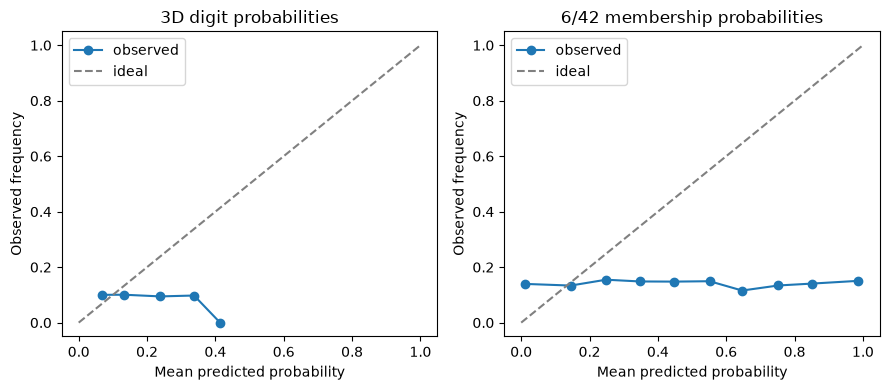

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, game, model, title in [(axes[0], '3d_lotto', 'multinomial_logistic_regression/all_features', '3D digit probabilities'), (axes[1], 'lotto_6_42', 'regularized_one_vs_rest_logistic_regression', '6/42 membership probabilities')]:
    bins = metrics['calibration'][game][model]['bins']
    rows = [row for row in bins if row['mean_probability'] is not None]
    ax.plot([row['mean_probability'] for row in rows], [row['observed_rate'] for row in rows], marker='o', label='observed')
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='ideal')
    ax.set(title=title, xlabel='Mean predicted probability', ylabel='Observed frequency')
    ax.legend()
fig.tight_layout()
plt.show()

# 16. Evidence Summary

**Question.** What do the full validation metrics, uncertainty intervals, folds, and baselines jointly show?

**Method.** Read the saved comparison, bootstrap, calibration, and simulation summaries.

**Interpretation.** The evidence summary is printed below.

**Limitation.** No single metric or model ranking establishes a predictive signal.


In [17]:
summary = {'validation': {}, 'bootstrap': metrics['bootstrap'], 'advancement_gate': metrics['advancement_gate']}
for game, methods in metrics['validation'].items():
    summary['validation'][game] = {name: {key: value for key, value in item.items() if key in ('mean_multinomial_negative_log_likelihood_per_digit', 'mean_multiset_overlap', 'mean_hits_at_6', 'mean_brier_42_label', 'mean_marginal_log_loss')} for name, item in methods['methods'].items() if name in ('uniform_random', 'expanding_historical_frequency', 'recent_30_frequency', 'multinomial_logistic_regression/all_features', 'regularized_one_vs_rest_logistic_regression/all_features', 'random_forest_multioutput_comparator/all_features')}
print(json.dumps(summary, indent=2))

{
  "validation": {
    "3d_lotto": {
      "uniform_random": {
        "mean_multinomial_negative_log_likelihood_per_digit": 1.7732979736623027,
        "mean_multiset_overlap": 0.7425955739972339
      },
      "expanding_historical_frequency": {
        "mean_multinomial_negative_log_likelihood_per_digit": 1.773773474966329,
        "mean_multiset_overlap": 0.8450899031811895
      },
      "multinomial_logistic_regression/all_features": {
        "mean_multinomial_negative_log_likelihood_per_digit": 1.8992462645315555,
        "mean_multiset_overlap": 0.7994467496542186
      }
    },
    "lotto_6_42": {
      "regularized_one_vs_rest_logistic_regression/all_features": {
        "mean_hits_at_6": 0.9233333333333333,
        "mean_brier_42_label": 0.3712404998794881,
        "mean_marginal_log_loss": 2.604837433189962
      },
      "random_forest_multioutput_comparator/all_features": {
        "mean_hits_at_6": 0.8833333333333333,
        "mean_brier_42_label": 0.12313540672861895,

# 17. Phase 5B Advancement Decision

**Question.** Does any candidate satisfy the predeclared evidence gate for a later test gate?

**Method.** Require validation improvement over fair random and historical baselines, fold consistency, acceptable calibration diagnostics, and a clean contamination audit.

**Interpretation.** The machine-readable decision is printed below.

**Limitation.** A passing result would only make a candidate ready for human review of the next gate.


In [18]:
print(json.dumps(metrics['advancement_gate'], indent=2))

{
  "any_candidate_eligible": false,
  "candidates": [
    {
      "candidate": "3d_lotto/multinomial_logistic_regression/all_features",
      "eligible": false,
      "primary_point_improvement_over_fair_random": false,
      "primary_point_improvement_over_historical_baselines": false,
      "folds_better_than_fair_random": 0,
      "folds_better_than_historical_baselines": 0,
      "fold_count": 3,
      "calibration_ece": 0.0396986313869143,
      "calibration_ece_screen_threshold": 0.1,
      "convergence_warning_count": 0,
      "empirical_p_raw": 0.013598640135986401,
      "empirical_p_gate": 0.013598640135986401,
      "checks": {
        "primary_point_improvement_over_fair_random": false,
        "primary_point_improvement_over_historical_baselines": false,
        "bootstrap_interval_excludes_zero_vs_fair_random": false,
        "bootstrap_interval_excludes_zero_vs_historical_baselines": false,
        "monte_carlo_empirical_p_passes_gate": true,
        "consistent_across_

# 18. Limitations

**Question.** What evidence remains unavailable?

**Method.** Keep the locked test unopened and treat all validation estimates as historical, finite-sample evidence. Training folds were also used to tune C, so their consistency check is diagnostic rather than an independent holdout.

**Interpretation.** The notebook provides no future predictions and no claim of lottery predictability.

**Limitation.** A later test evaluation requires a separately authorized phase and untouched test outcomes.
